# Sachs — Fixed Hyperparameters Benchmark

Run all algorithms with manually chosen hyperparameters on the Sachs protein signaling dataset and visualize the results.

In [1]:
import sys; sys.path.insert(0, "..")
%load_ext autoreload
%autoreload 2

from pipeline.Benchmark import Benchmark

/home/mathis/Documents/Travail/cbnsl_benchmark/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
bench = Benchmark.sachs(variant="raw")

In [3]:
# From the grid search with the metrics on CPDAGs
configs = {
    "CPC":           {"alpha": 0.01, "max_conditioning_set_size": 2},
    "CMIIC":         {"alpha": 0.05},
    "MIIC":          {"n_bins": 2, "discretization_method": "quantile"},
    "GHC+BDeu":      {"n_bins": 2, "discretization_method": "quantile"},
    "NOTEARS":       {"lambda1": 0.5, "w_threshold_notears": 0.1},
    "NOTEARS Disc.": {"lambda1": 0., "w_threshold_notears": 0.1, "n_bins": 4, "discretization_method": "hartemink", "initial_bins": 20},
    "LiNGAM":        {"threshold_lingam": 0.075},
}
"""
# From the grid search on the synthetic datasets
configs = {
    "CPC":           {"alpha": 0.05, "max_conditioning_set_size": 3},
    "CMIIC":         {"alpha": 0.05},
    "MIIC":          {"n_bins": 4, "discretization_method": "quantile"},
    "GHC+BDeu":      {"n_bins": 4, "discretization_method": "quantile"},
    "NOTEARS":       {"lambda1": 0., "w_threshold_notears": 0.3},
    "NOTEARS Disc.": {"lambda1": 0.1, "w_threshold_notears": 0.1, "n_bins": 4, "discretization_method": "quantile"},
    "LiNGAM":        {"threshold_lingam": 0.1},
}
"""

'\n# From the grid search on the synthetic datasets\nconfigs = {\n    "CPC":           {"alpha": 0.05, "max_conditioning_set_size": 3},\n    "CMIIC":         {"alpha": 0.05},\n    "MIIC":          {"n_bins": 4, "discretization_method": "quantile"},\n    "GHC+BDeu":      {"n_bins": 4, "discretization_method": "quantile"},\n    "NOTEARS":       {"lambda1": 0., "w_threshold_notears": 0.3},\n    "NOTEARS Disc.": {"lambda1": 0.1, "w_threshold_notears": 0.1, "n_bins": 4, "discretization_method": "quantile"},\n    "LiNGAM":        {"threshold_lingam": 0.1},\n}\n'

## Run

In [4]:
bench.run_fixed(configs)

  CPC: OK
  CMIIC: OK
  MIIC: OK
  GHC+BDeu: OK
  NOTEARS: OK


Hartemink merging: 100%|██████████| 176/176 [00:19<00:00,  8.82it/s]


  NOTEARS Disc.: OK
  LiNGAM: OK
Done.



Benchmark(dataset='sachs_raw__11vars_853s', 7 algorithms)

## Golden structure

Golden CPDAG: 18 arcs, 0 edges


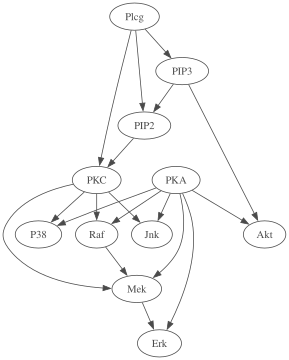

In [5]:
bench.show_golden()

## Best scores (CPDAG)

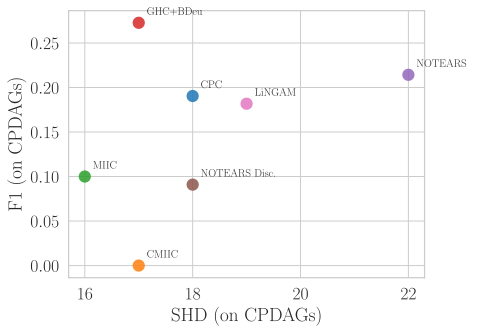

In [6]:
bench.plot_best_scores("cpdag")

## Best scores (Skeleton)

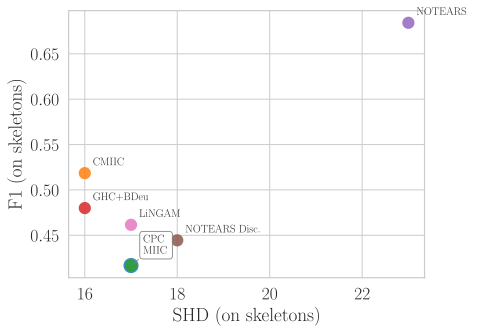

In [7]:
bench.plot_best_scores("skeleton")

## Learned structures

In [8]:
bench.plot_structures(save_dir="figures/sachs_structures")

  Saved golden
  Saved CPC
  Saved CMIIC
  Saved MIIC
  Saved GHC_BDeu
  Saved NOTEARS
  Saved NOTEARS_Disc.
  Saved LiNGAM


## Pairwise heatmaps (CPDAG)

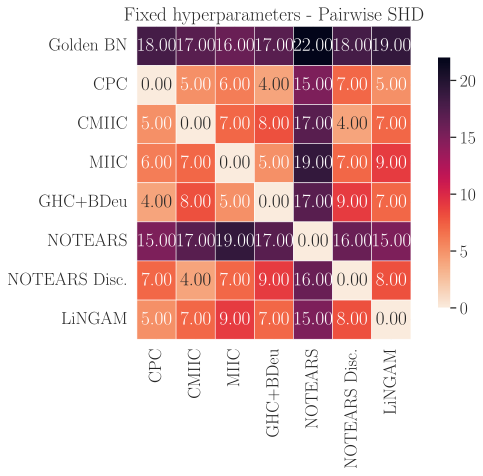

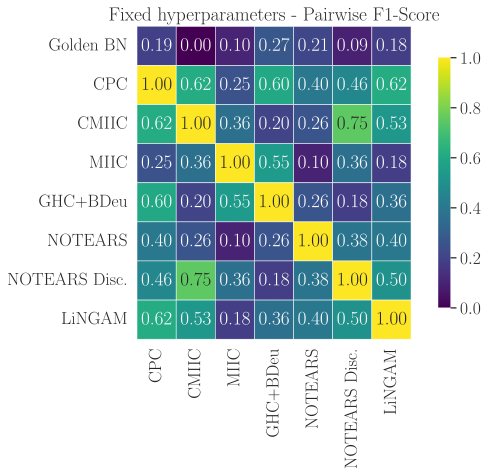

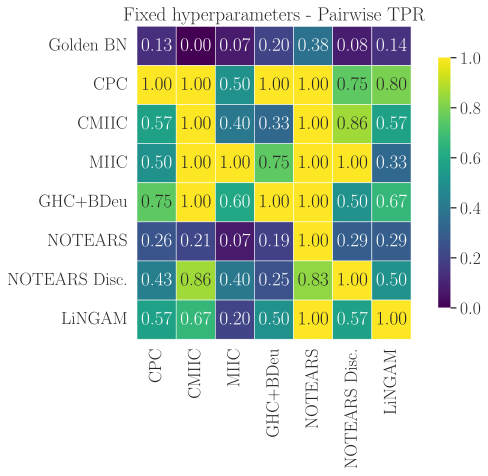

In [9]:
bench.plot_pairwise_heatmaps("cpdag")

## Pairwise heatmaps (Skeleton)

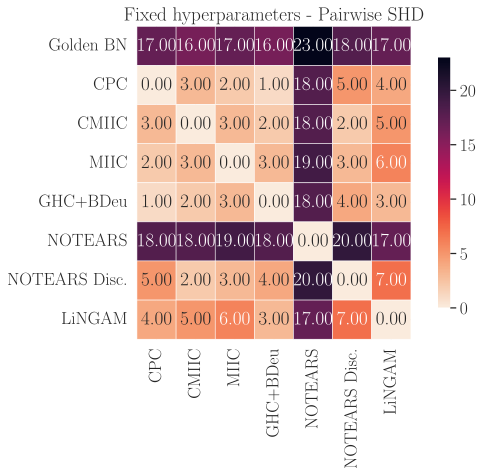

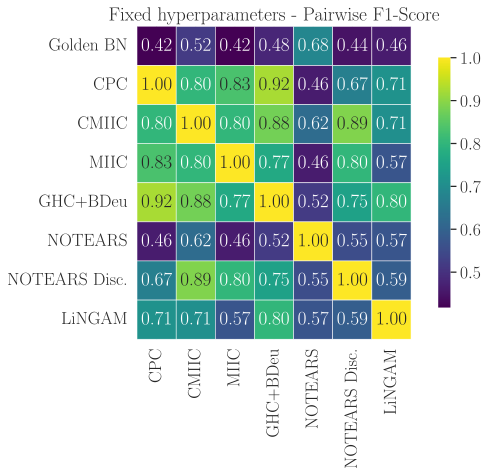

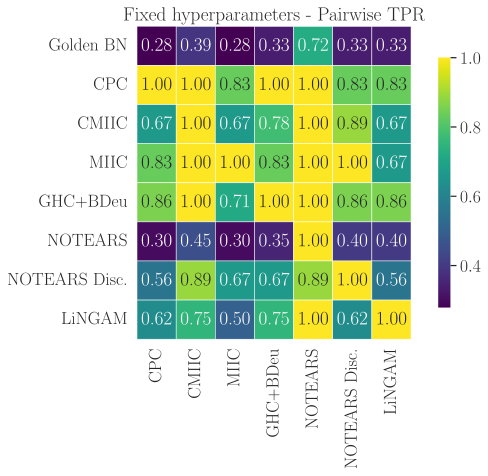

In [10]:
bench.plot_pairwise_heatmaps("skeleton")

In [12]:
!jupyter nbconvert --to html ./sachs_visualize_fixed.ipynb

[NbConvertApp] Converting notebook ./sachs_visualize_fixed.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 1153274 bytes to sachs_visualize_fixed.html
